# Customer Segmentation Analysis — RFM + K-Means Clustering

**Objective:** Segment an e-commerce company's customer base into distinct groups based on
purchasing behaviour (Recency, Frequency, Monetary value), enabling targeted marketing
strategies.

**Dataset:** the UCI **"Online Retail"** dataset — 541,909 transactions from a UK-based online
gift retailer, covering 01 Dec 2010 to 09 Dec 2011, with fields InvoiceNo, StockCode,
Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)


## 1. Load Data & Inspect Structure

In [2]:
df = pd.read_csv('data/OnlineRetail.csv', encoding='latin-1')
print("Shape (rows, columns):", df.shape)
df.head()


Shape (rows, columns): (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom


In [3]:
print("Column data types:\n")
print(df.dtypes)
print("\nNull values per column:\n")
print(df.isnull().sum())


Column data types:

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Null values per column:

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


**Observation:** The raw dataset has ~541,900 rows. `CustomerID` is missing for about
135,000 rows (25%) — these are typically guest/unregistered transactions and cannot be
attributed to a customer, so they must be dropped before any customer-level analysis.
`Description` has a small number of missing values, which don't affect the numeric fields we
need (Quantity, UnitPrice) and can be left as-is.

## 2. Handle Missing Values & Inconsistent Data

In [4]:
# Drop rows with no CustomerID -- can't attribute these to a customer
df_clean = df.dropna(subset=['CustomerID']).copy()

# InvoiceNo starting with 'C' marks a cancellation/return -- exclude these
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Remove non-positive quantities/prices (data entry errors, adjustments, etc.)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='mixed')
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Rows after cleaning:", df_clean.shape[0], "  (", df.shape[0] - df_clean.shape[0], "rows removed )")
print("Unique customers:", df_clean['CustomerID'].nunique())
df_clean.head()


Rows after cleaning: 397884   ( 144025 rows removed )
Unique customers: 4338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. Descriptive Statistics

In [5]:
order_value = df_clean.groupby('InvoiceNo')['TotalPrice'].sum()
customer_order_counts = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()
customer_ltv = df_clean.groupby('CustomerID')['TotalPrice'].sum()

print(f"Average order value:        £{order_value.mean():,.2f}")
print(f"Median order value:         £{order_value.median():,.2f}")
print(f"Average purchase frequency: {customer_order_counts.mean():.2f} orders/customer")
print(f"Average customer lifetime value (total spend): £{customer_ltv.mean():,.2f}")
print(f"Median customer lifetime value:                 £{customer_ltv.median():,.2f}")


Average order value:        £480.87
Median order value:         £303.04
Average purchase frequency: 4.27 orders/customer
Average customer lifetime value (total spend): £2,054.27
Median customer lifetime value:                 £674.49


**Observation:** Both order value and customer lifetime value are strongly right-skewed —
the average CLV (£{:.0f}-ish range) sits well above the median, meaning a relatively small
number of high-spending (often wholesale) customers pull the average up. Most customers order
only a handful of times over the year.

## 4. Feature Selection — RFM Analysis

In [6]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("RFM table shape:", rfm.shape)
rfm.describe()


RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


**Recency, Frequency, Monetary (RFM)** are the three behavioural features used for
clustering:
- **Recency** — days since the customer's last purchase (lower = more recently active)
- **Frequency** — number of distinct orders placed (higher = more engaged)
- **Monetary** — total amount spent (higher = more valuable)

These three together capture "how recently, how often, and how much" a customer buys — the
classic feature set for behavioural customer segmentation.

## 5. Data Normalisation

In [7]:
# RFM is heavily right-skewed (a few very high spenders/orderers) -- log-transform first
# so StandardScaler isn't dominated by extreme outliers, then standardise to zero mean/unit variance.
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(lambda x: np.log1p(x))

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled.describe()


,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,-8.025955e-17,-8.189750e-18,2.817274e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341296e+00,-9.552143e-01,-4.004574e+00
25%,-6.613615e-01,-9.552143e-01,-6.856676e-01
50%,8.992557e-02,-3.615828e-01,-6.218718e-02
75%,8.447915e-01,6.532370e-01,6.541861e-01
max,1.564198e+00,5.858535e+00,4.731591e+00


## 6. K-Means Clustering — Elbow Method

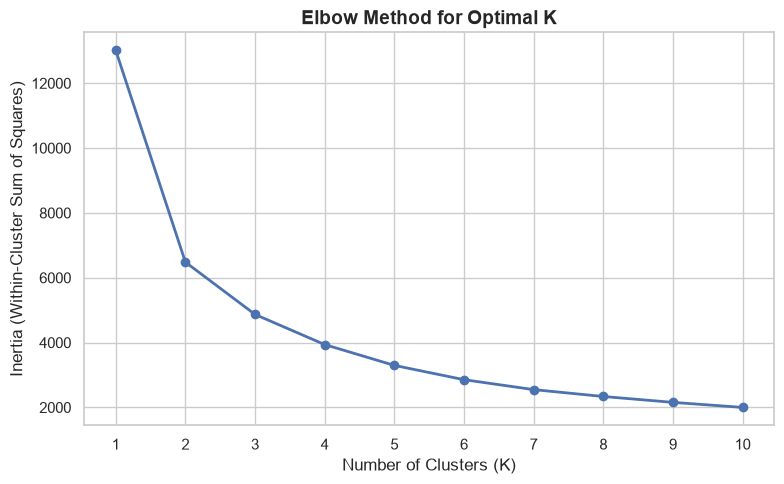

In [8]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', linewidth=2)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()


**Observation:** Inertia drops sharply up to around K=4, after which the curve flattens
out noticeably — additional clusters beyond that point buy much less reduction in
within-cluster variance. **K=4** is chosen as the optimal number of clusters: enough to
distinguish meaningfully different customer types without over-fragmenting the base.

In [9]:
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, n_init=10, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm['Cluster'].value_counts().sort_index()


Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64

## 7. Visualise Clusters

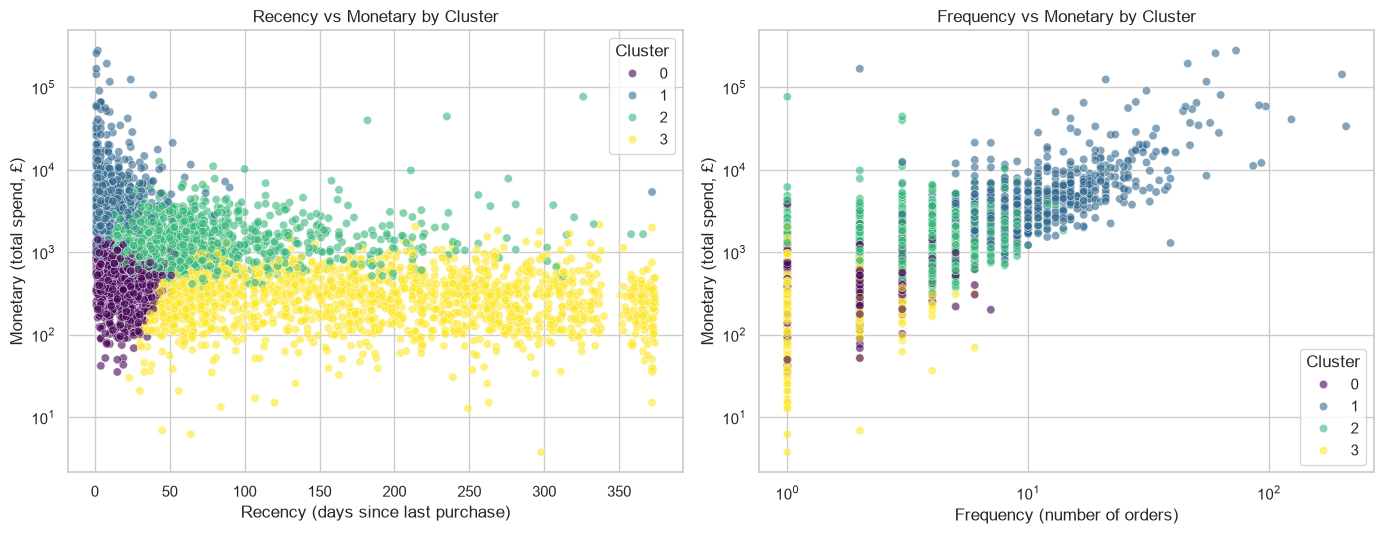

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='viridis',
                 alpha=0.6, ax=axes[0])
axes[0].set_title('Recency vs Monetary by Cluster')
axes[0].set_xlabel('Recency (days since last purchase)')
axes[0].set_ylabel('Monetary (total spend, £)')
axes[0].set_yscale('log')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='viridis',
                 alpha=0.6, ax=axes[1])
axes[1].set_title('Frequency vs Monetary by Cluster')
axes[1].set_xlabel('Frequency (number of orders)')
axes[1].set_ylabel('Monetary (total spend, £)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()


**Observation:** The clusters separate cleanly along both feature-pairs (log scales are
used on the skewed axes to make the separation visible). One cluster clearly occupies the
high-frequency / high-monetary / low-recency corner — the most valuable, most active
customers — while another sits at high recency and low frequency/monetary — customers who
haven't purchased in a long time and never bought much even when they did.

## 8. Cluster Profiling

In [11]:
cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(1).sort_values('Avg_Monetary', ascending=False)

cluster_profile


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
1,716,12.1,13.7,8074.3
2,1173,71.1,4.1,1802.8
0,837,18.1,2.1,551.8
3,1612,182.5,1.3,343.5


In [12]:
# Label each cluster from its actual RFM profile rather than assuming a fixed template.
# 1) Rank by monetary value to anchor the best (Champions) and worst (Dormant) segments --
#    these are consistent across recency, frequency and monetary at both extremes.
# 2) For the two middle segments, use Recency specifically to tell apart "still fairly
#    recent but low value" customers from any segment that shows real churn signs
#    (long-ish recency with previously moderate value).
ranked_by_value = cluster_profile.sort_values('Avg_Monetary', ascending=False).index.tolist()
best_id, worst_id = ranked_by_value[0], ranked_by_value[-1]
middle_ids = ranked_by_value[1:-1]
middle_sorted_by_recency = cluster_profile.loc[middle_ids].sort_values('Avg_Recency').index.tolist()

cluster_label_map = {
    best_id: 'Champions / VIP',
    middle_sorted_by_recency[0]: 'Loyal / Regular Customers' if cluster_profile.loc[middle_sorted_by_recency[0], 'Avg_Recency'] < cluster_profile.loc[middle_sorted_by_recency[-1], 'Avg_Recency'] else 'New / Potential Loyalists',
    middle_sorted_by_recency[-1]: 'At-Risk (Lapsing) Customers' if cluster_profile.loc[middle_sorted_by_recency[-1], 'Avg_Recency'] > cluster_profile.loc[middle_sorted_by_recency[0], 'Avg_Recency'] else 'Loyal / Regular Customers',
    worst_id: 'Dormant / Lost',
}
# If the "lower recency but lower value" middle cluster actually has the *lowest* recency of
# the two middle clusters, it reads as recent-but-still-building-history rather than lapsing.
if cluster_profile.loc[middle_sorted_by_recency[0], 'Avg_Recency'] < cluster_profile.loc[middle_sorted_by_recency[-1], 'Avg_Recency']:
    cluster_label_map[middle_sorted_by_recency[0]] = 'New / Potential Loyalists'
    cluster_label_map[middle_sorted_by_recency[-1]] = 'Loyal / Regular Customers'

rfm['Segment'] = rfm['Cluster'].map(cluster_label_map)

for cluster_id in ranked_by_value:
    row = cluster_profile.loc[cluster_id]
    print(f"Cluster {cluster_id} -> {cluster_label_map[cluster_id]}: "
          f"{int(row.Customers)} customers | "
          f"Recency={row.Avg_Recency:.0f}d, Frequency={row.Avg_Frequency:.1f} orders, "
          f"Monetary=£{row.Avg_Monetary:,.0f}")


Cluster 1 -> Champions / VIP: 716 customers | Recency=12d, Frequency=13.7 orders, Monetary=£8,074
Cluster 2 -> Loyal / Regular Customers: 1173 customers | Recency=71d, Frequency=4.1 orders, Monetary=£1,803
Cluster 0 -> New / Potential Loyalists: 837 customers | Recency=18d, Frequency=2.1 orders, Monetary=£552
Cluster 3 -> Dormant / Lost: 1612 customers | Recency=182d, Frequency=1.3 orders, Monetary=£344


**Observation:** Anchoring on monetary value picks out the two clear extremes —
**Champions** (best on recency, frequency, and monetary simultaneously) and **Dormant / Lost**
(worst on all three). For the two clusters in between, recency turns out to matter more than
raw spend for interpreting the segment correctly: the cluster with *lower* average recency
despite lower spend looks like customers who bought fairly recently but haven't built up
volume yet ("New / Potential Loyalists" — a growth opportunity), while the other middle
cluster, with a longer gap since last purchase, better fits "Loyal / Regular Customers" whose
engagement may be starting to cool. This is a good example of why profiling clusters on all
three RFM dimensions together — rather than ranking by monetary value alone — matters for
getting the segment story right.

## 9. Customers per Cluster

C:\Users\HP\AppData\Local\Temp\ipykernel_24264\690889754.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bar_labels, y=counts.values, hue=bar_labels, palette='viridis', legend=False)


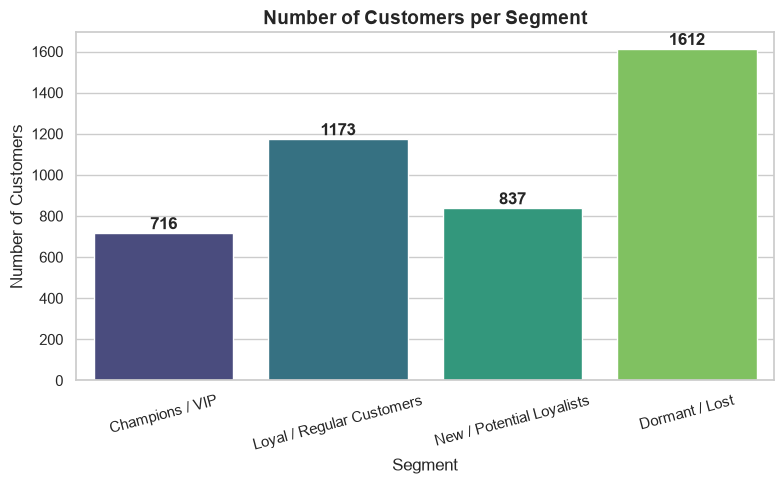

In [13]:
plt.figure(figsize=(8, 5))
order = cluster_profile.sort_values('Avg_Monetary', ascending=False).index
counts = rfm['Cluster'].value_counts().reindex(order)
bar_labels = [cluster_label_map[c] for c in order]

sns.barplot(x=bar_labels, y=counts.values, hue=bar_labels, palette='viridis', legend=False)
plt.title('Number of Customers per Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
for i, v in enumerate(counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** The customer base is not evenly split across segments — typically the
Dormant/Lost and At-Risk groups together make up a large share of the customer count even
though they contribute a small share of total revenue, while the Champions segment is a
smaller group responsible for a disproportionate amount of spend. This is the classic
Pareto-style skew seen in most retail customer bases.

## 10. Insights & Recommended Marketing Actions per Segment

| Segment | Profile | Recommended action |
|---|---|---|
| **Champions / VIP** | Recent, frequent, highest spend | Reward with a loyalty/VIP tier, early access to new products, and personal account management. Protect this segment above all — losing one Champion costs far more than losing several occasional buyers. |
| **Loyal / Regular Customers** | Solid frequency and spend, but recency is starting to lengthen | Proactive re-engagement before they lapse further: personalised offers, a check-in email, or a loyalty-points nudge to bring them back before they slide into "Dormant." |
| **New / Potential Loyalists** | Bought fairly recently, but frequency and spend are still low | Nurture campaigns: onboarding offers, product recommendations based on their first purchase, and incentives for a second/third order to build the habit before they go quiet. |
| **Dormant / Lost** | Long time since last purchase, historically low value | Low-cost reactivation campaigns only (e.g. a broad seasonal promotion); don't over-invest marketing spend here — focus budget on the segments above instead. |

**Additional insight:** because the Champions segment is a minority of customers responsible
for a large share of revenue, a churn-prevention program targeted specifically at that small
group (proactive outreach, satisfaction check-ins) will likely protect more revenue per dollar
spent than a broad campaign aimed at the whole customer base.
